Fasion CIFAR Classification Project

In [2]:
print('Importing necessary libraries.')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from tensorflow import keras
import tensorflow as tf

print('Importing necessary libraries completed')

Importing necessary libraries.
Importing necessary libraries completed


In [3]:
# Loading dataset now
(cifar100_train_images, cifar100_train_labels), (cifar100_test_images, cifar100_test_labels) = keras.datasets.cifar100.load_data()
print(cifar100_train_images.shape)
print(cifar100_train_labels.shape)
print(cifar100_test_images.shape)
print(cifar100_test_labels.shape)
# print(cifar100_train_labels[0])
print(cifar100_train_images[0])

169001437/169001437 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)
[[[255 255 255]
  [255 255 255]
  [255 255 255]
  ...
  [195 205 193]
  [212 224 204]
  [182 194 167]]

 [[255 255 255]
  [254 254 254]
  [254 254 254]
  ...
  [170 176 150]
  [161 168 130]
  [146 154 113]]

 [[255 255 255]
  [254 254 254]
  [255 255 255]
  ...
  [189 199 169]
  [166 178 130]
  [121 133  87]]

 ...

 [[148 185  79]
  [142 182  57]
  [140 179  60]
  ...
  [ 30  17   1]
  [ 65  62  15]
  [ 76  77  20]]

 [[122 157  66]
  [120 155  58]
  [126 160  71]
  ...
  [ 22  16   3]
  [ 97 112  56]
  [141 161  87]]

 [[ 87 122  41]
  [ 88 122  39]
  [101 134  56]
  ...
  [ 34  36  10]
  [105 133  59]
  [138 173  79]]]


In [4]:
# Normalize the data

cifar100_train_images = cifar100_train_images / 255.0
cifar100_test_images = cifar100_test_images / 255.0

In [5]:
# Original shapes are (50000, 32, 32, 3) and (10000, 32, 32, 3)
# To reduce the size to 28x28 pixels while keeping 3 channels, we need to explicitly resize the images.

# Ensure tensorflow is imported, which it should be via keras
import tensorflow as tf

# Resize images to 28x28 pixels, preserving the 3 color channels  # why he gave [0] here wont that cause only 1st element to change?
train_images = tf.image.resize(cifar100_train_images, (28, 28)).numpy()
test_images = tf.image.resize(cifar100_test_images, (28, 28)).numpy()

print(f"New train_images shape: {train_images.shape}")
print(f"New test_images shape: {test_images.shape}")

New train_images shape: (50000, 28, 28, 3)
New test_images shape: (10000, 28, 28, 3)


In [6]:
# one hot encoding labels
train_labels_one_hot = tf.keras.utils.to_categorical(cifar100_train_labels, num_classes=100)
test_labels_one_hot = tf.keras.utils.to_categorical(cifar100_test_labels,num_classes=100)


In [7]:
#  Checking for shapes of datasets

print('CIFAR_100 train images:',train_images.shape)
print('CIFAR_100_test images: ',test_images.shape)

CIFAR_100 train images: (50000, 28, 28, 3)
CIFAR_100_test images:  (10000, 28, 28, 3)


Model Building

In [8]:
# Model building
# This is ANN model

ann_model = keras.models.Sequential()
ann_model.add(keras.layers.Flatten(input_shape=[28,28,3]))
ann_model.add(keras.layers.Dense(300,activation='relu'))
ann_model.add(keras.layers.Dense(100,activation='relu'))
ann_model.add(keras.layers.Dense(100,activation='softmax'))

ann_model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

ann_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 2352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 300)            │       705,900 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        10,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 746,100 (2.85 MB)

 Trainable params: 746,100 (2.85 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Basic CNN model
basic_cnn_model = keras.models.Sequential()
basic_cnn_model.add(keras.layers.Conv2D(filters=32,kernel_size=3,input_shape=[28,28,3],activation='relu'))
basic_cnn_model.add(keras.layers.MaxPool2D(pool_size=(2,2)))
basic_cnn_model.add(keras.layers.Flatten())
basic_cnn_model.add(keras.layers.Dense(150,activation='relu'))
basic_cnn_model.add(keras.layers.Dense(100,activation='softmax'))

basic_cnn_model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

basic_cnn_model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 5408)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 150)            │       811,350 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 100)            │        15,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 827,346 (3.16 MB)

 Trainable params: 827,346 (3.16 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
# Deeper CNN model

deep_cnn_model = keras.models.Sequential()
deep_cnn_model.add(keras.layers.Conv2D(filters=32,kernel_size=3,input_shape=[28,28,3],activation='relu'))
deep_cnn_model.add(keras.layers.MaxPool2D(pool_size=(2,2)))
deep_cnn_model.add(keras.layers.Conv2D(filters=64,kernel_size=3,activation='relu'))
deep_cnn_model.add(keras.layers.MaxPool2D(pool_size=(2,2)))
deep_cnn_model.add(keras.layers.Flatten())
deep_cnn_model.add(keras.layers.Dense(150,activation='relu'))
deep_cnn_model.add(keras.layers.Dense(100,activation='softmax'))

deep_cnn_model.compile(loss='categorical_crossentropy',optimizer='adam',metrics=['accuracy'])

deep_cnn_model.summary()


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 150)            │       240,150 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        15,100 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 274,642 (1.05 MB)

 Trainable params: 274,642 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

In [23]:
# Training ANN model
early_stopping = keras.callbacks.EarlyStopping(patience=5,restore_best_weights=True)
model_checkpoint_ann = keras.callbacks.ModelCheckpoint('ann_model_weights.weights.h5',monitor='val_loss',save_best_only=True,save_weights_only=True,mode='min',verbose=1)

print('Training ANN model.....')

ann_history = ann_model.fit(train_images,train_labels_one_hot,epochs=100,
              validation_data=(test_images,test_labels_one_hot),
              callbacks=[early_stopping,model_checkpoint_ann],
              batch_size=100)



Training ANN model.....
Epoch 1/100
485/500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2590 - loss: 3.0011
Epoch 1: val_loss improved from inf to 3.28501, saving model to ann_model_weights.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2589 - loss: 3.0017 - val_accuracy: 0.2226 - val_loss: 3.2850
Epoch 2/100
496/500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2625 - loss: 2.9970
Epoch 2: val_loss did not improve from 3.28501
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2625 - loss: 2.9971 - val_accuracy: 0.2201 - val_loss: 3.2998
Epoch 3/100
484/500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2630 - loss: 2.9772
Epoch 3: val_loss did not improve from 3.28501
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2630 - loss: 2.9776 - val_accuracy: 0.2257 - val_loss: 3.2868
Epoch 4/100
496/500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2686 - loss: 2.9574
Epoch 4: val_loss improved from 3.28501 to 3.27611, saving model to ann_model_weights.weig

In [15]:
# Training Basic CNN model
model_checkpoint_basic_cnn = keras.callbacks.ModelCheckpoint('basic_cnn_model_weights.weights.h5',monitor='val_loss',save_best_only=True,save_weights_only=True,mode='min',verbose=1)

print('Training Basic CNN model.....')

basic_cnn_history = basic_cnn_model.fit(train_images,train_labels_one_hot,epochs=100,
              validation_data=(test_images,test_labels_one_hot),
              callbacks=[early_stopping,model_checkpoint_basic_cnn],
              batch_size=100)

print("Basic CNN modle trainning has finished")


Training Basic CNN model.....
Epoch 1/100
488/500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0561 - loss: 4.2790
Epoch 1: val_loss improved from inf to 3.61840, saving model to basic_cnn_model_weights.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.0571 - loss: 4.2719 - val_accuracy: 0.1633 - val_loss: 3.6184
Epoch 2/100
498/500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1766 - loss: 3.5027
Epoch 2: val_loss improved from 3.61840 to 3.33174, saving model to basic_cnn_model_weights.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.1766 - loss: 3.5022 - val_accuracy: 0.2067 - val_loss: 3.3317
Epoch 3/100
483/500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2286 - loss: 3.1943
Epoch 3: val_loss improved from 3.33174 to 3.13103, saving model to basic_cnn_model_weights.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2289 - loss: 3.1931 - val_accuracy: 0.2439 - val_loss: 3.1310
Epoch 4/100
498/500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 

In [16]:
# Training Deeper CNN model

model_checkpoint_deep_cnn = keras.callbacks.ModelCheckpoint('deep_cnn_model_weights.weights.h5',
                                                            monitor='val_loss',
                                                            save_best_only=True,
                                                            save_weights_only=True,
                                                            mode='min',verbose=1)

print('Training Deeper CNN model.....')

deep_cnn_history = deep_cnn_model.fit(train_images,train_labels_one_hot,epochs=100,
              validation_data=(test_images,test_labels_one_hot),
              callbacks=[early_stopping,model_checkpoint_deep_cnn],
              batch_size=100)

print("Deeper CNN modle trainning has finished")


Training Deeper CNN model.....
Epoch 1/100
489/500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.0687 - loss: 4.1977
Epoch 1: val_loss improved from inf to 3.43604, saving model to deep_cnn_model_weights.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.0698 - loss: 4.1901 - val_accuracy: 0.1907 - val_loss: 3.4360
Epoch 2/100
490/500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2080 - loss: 3.3083
Epoch 2: val_loss improved from 3.43604 to 3.10287, saving model to deep_cnn_model_weights.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2083 - loss: 3.3065 - val_accuracy: 0.2525 - val_loss: 3.1029
Epoch 3/100
493/500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.2728 - loss: 2.9679
Epoch 3: val_loss improved from 3.10287 to 2.93072, saving model to deep_cnn_model_weights.weights.h5
500/500 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2729 - loss: 2.9674 - val_accuracy: 0.2848 - val_loss: 2.9307
Epoch 4/100
486/500 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - 

Model Evaluation

In [17]:
ann_model.evaluate(test_images,test_labels_one_hot)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2304 - loss: 3.2569


[3.2660470008850098, 0.23229999840259552]

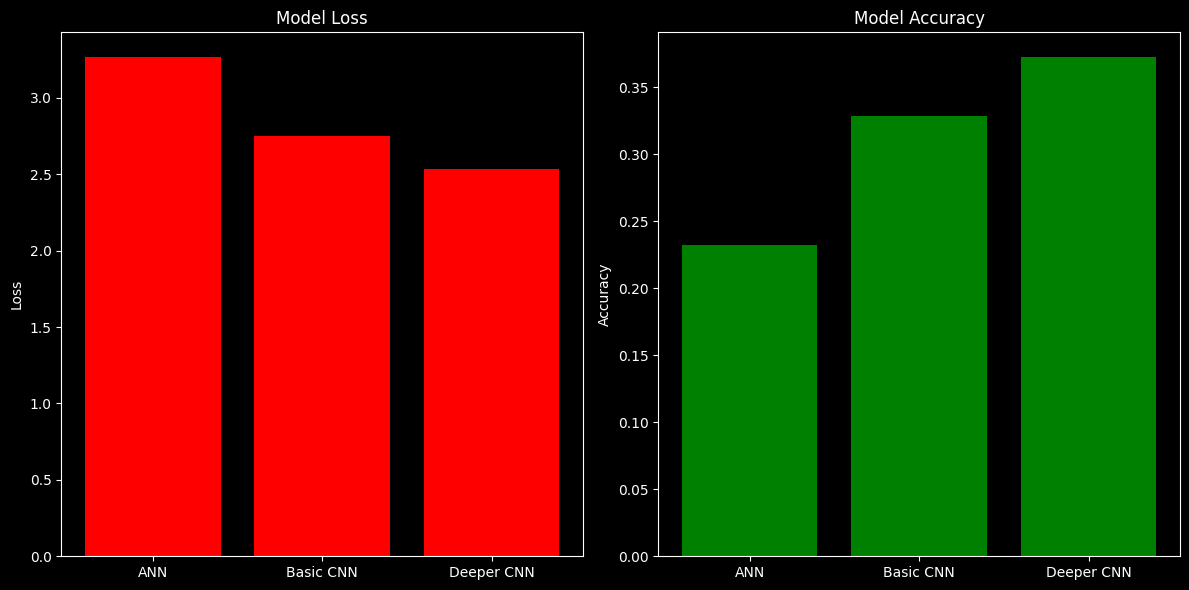

In [18]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix,classification_report

ann_model.load_weights('ann_model_weights.weights.h5')
basic_cnn_model.load_weights('basic_cnn_model_weights.weights.h5')
deep_cnn_model.load_weights('deep_cnn_model_weights.weights.h5')

loss_ann,accu_ann = ann_model.evaluate(test_images,test_labels_one_hot,verbose=0)
loss_basic_cnn,accu_basic_cnn = basic_cnn_model.evaluate(test_images,test_labels_one_hot,verbose=0)
loss_deep_cnn,accu_deep_cnn = deep_cnn_model.evaluate(test_images,test_labels_one_hot,verbose=0)


# Data
models = ['ANN','Basic CNN','Deeper CNN']
loss = [loss_ann,loss_basic_cnn,loss_deep_cnn]
accuracy = [accu_ann,accu_basic_cnn,accu_deep_cnn]

# Dark mode style
plt.style.use('dark_background')
fix,ax = plt.subplots(1,2,figsize=(12,6))

# Loss plot
ax[0].bar(models,loss,color='red')
ax[0].set_title('Model Loss',color='white')
ax[0].set_ylabel('Loss',color='white')
ax[0].tick_params(axis='x',colors='white')
ax[0].tick_params(axis='y',colors='white')

# Accuracy plot
ax[1].bar(models,accuracy,color='green')
ax[1].set_title('Model Accuracy',color='white')
ax[1].set_ylabel('Accuracy',color='white')
ax[1].tick_params(axis='x',colors='white')
ax[1].tick_params(axis='y',colors='white')

plt.tight_layout()
plt.show()




313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


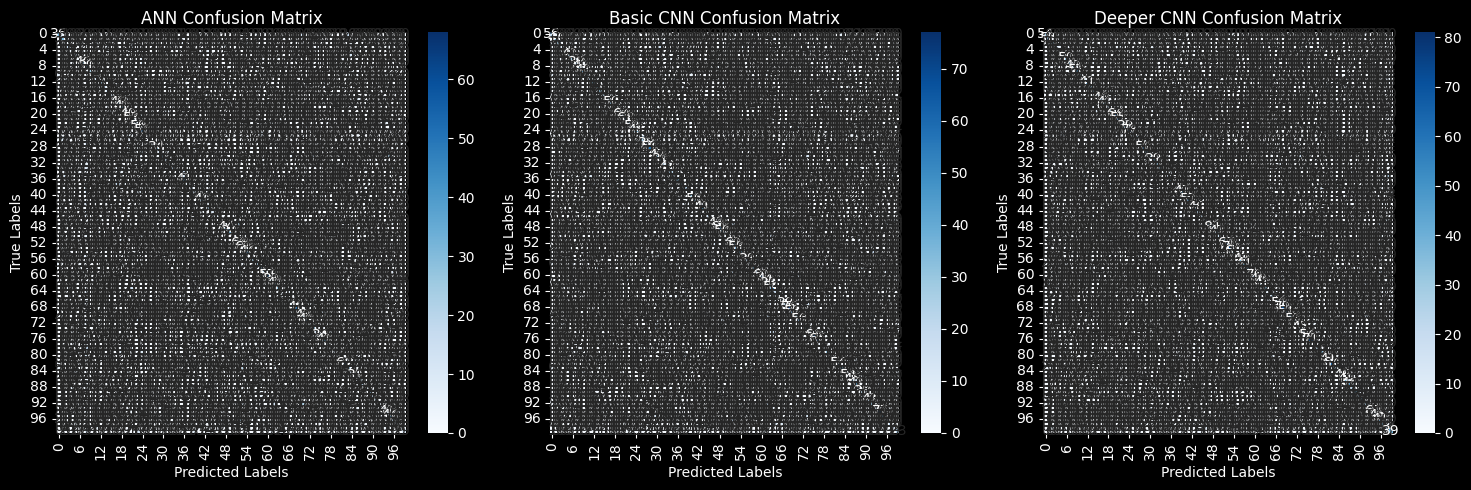

In [21]:
# Model evaulation (Confusion matrix and report)
import seaborn as sns

# Predictions
pred_ann = ann_model.predict(test_images)
pred_basic_cnn = basic_cnn_model.predict(test_images)
pred_deep_cnn = deep_cnn_model.predict(test_images)

# Convert labels
text_labels = np.argmax(test_labels_one_hot,axis=1)

ann_pred_labels = np.argmax(pred_ann,axis=1)
basic_cnn_pred = np.argmax(pred_basic_cnn,axis=1)
deep_cnn_pred = np.argmax(pred_deep_cnn,axis=1)

# Confusion matrix

cm_ann = confusion_matrix(text_labels,ann_pred_labels)
cm_basic_cnn = confusion_matrix(text_labels,basic_cnn_pred)
cm_deep_cnn = confusion_matrix(text_labels,deep_cnn_pred)

fig, ax = plt.subplots(1,3,figsize=(17,5))

sns.heatmap(cm_ann,annot=True,fmt='d',cmap='Blues',ax=ax[0])
ax[0].set_title('ANN Confusion Matrix')
ax[0].set_xlabel('Predicted Labels')
ax[0].set_ylabel('True Labels')

sns.heatmap(cm_basic_cnn,annot=True,fmt='d',cmap='Blues',ax=ax[1])
ax[1].set_title('Basic CNN Confusion Matrix')
ax[1].set_xlabel('Predicted Labels')
ax[1].set_ylabel('True Labels')

sns.heatmap(cm_deep_cnn,annot=True,fmt='d',cmap='Blues',ax=ax[2])
ax[2].set_title('Deeper CNN Confusion Matrix')
ax[2].set_xlabel('Predicted Labels')
ax[2].set_ylabel('True Labels')

plt.tight_layout()
plt.show()

In [24]:
# Model Comparison
import plotly.graph_objects as go
from plotly.subplots import make_subplots

models = {'ANN':('cyan',ann_history.history),
          'Basic CNN':('green',basic_cnn_history.history),
          'Deeper CNN':('red',deep_cnn_history.history)}

performance_data = {
    'Model': ['ANN', 'Basic CNN', 'Deeper CNN'],
    'Test Loss': [loss_ann, loss_basic_cnn, loss_deep_cnn],
    'Test Accuracy': [accu_ann, accu_basic_cnn, accu_deep_cnn]
}

performance_df = pd.DataFrame(performance_data)

fig = make_subplots(rows=1,cols=2,subplot_titles=('Model Loss','Model Accuracy'))

for name,(color,history) in models.items():
  #accuracy
    fig.add_trace(go.Scatter(x=history['loss'],mode='lines',name=name,line=dict(color=color)),row=1,col=1)
    fig.add_trace(go.Scatter(x=history['accuracy'],mode='lines',name=name,line=dict(color=color)),row=1,col=2)

    #loss
    fig.add_trace(go.Scatter(x=history['loss'],mode='lines',name=name,line=dict(color=color)),row=1,col=1)

fig.update_layout(title_text='Model Performance Comparison',showlegend=True)
fig.show()



313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


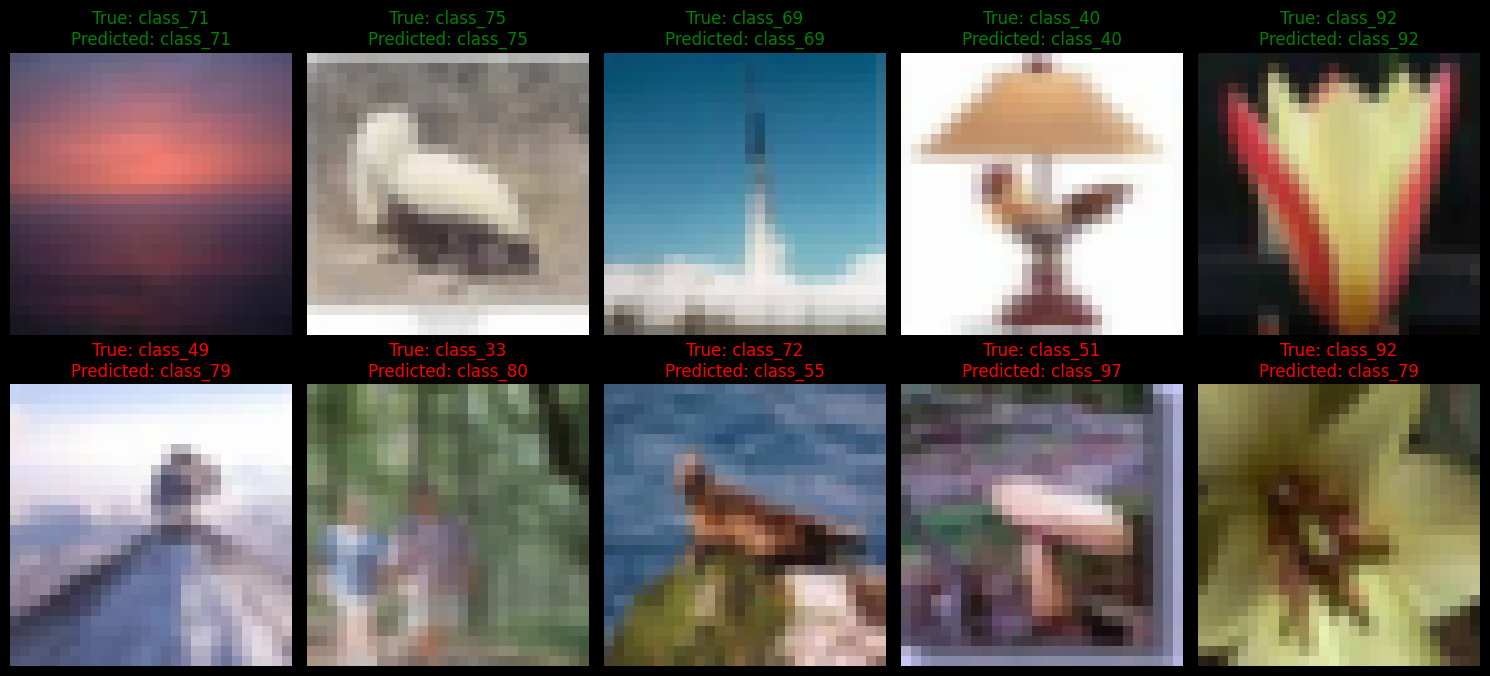

In [26]:
# Predictions

basic_cnn_predictionn = basic_cnn_model.predict(test_images)
basic_cnn_prediction_labels = np.argmax(basic_cnn_predictionn,axis=1)

correctly_classified_indices = np.where(basic_cnn_prediction_labels == text_labels)[0]
incorrectly_classified_indices = np.where(basic_cnn_prediction_labels != text_labels)[0]

# Update class_names to 100 classes (placeholder names since actual CIFAR-100 names are not available in context)
class_names = [f'class_{i}' for i in range(100)]

num_correct_to_show = 5
num_incorrect_to_show = 5

num_correct_to_show = min(num_correct_to_show, len(correctly_classified_indices))
num_incorrect_to_show = min(num_incorrect_to_show, len(incorrectly_classified_indices))

num_columns = 5
num_rows = 2
fig, axes = plt.subplots(num_rows, num_columns, figsize=(15, 7))
axes = axes.flatten() # Flatten the 2D array of axes for easier iteration

# Display correctly classified images
for i in range(num_correct_to_show):
    idx = correctly_classified_indices[i]
    ax = axes[i]
    ax.imshow(test_images[idx])
    ax.set_title(f"True: {class_names[text_labels[idx]]}\nPredicted: {class_names[basic_cnn_prediction_labels[idx]]}", color='green')
    ax.axis('off')

# Display incorrectly classified images
for i in range(num_incorrect_to_show):
    idx = incorrectly_classified_indices[i]
    ax = axes[num_correct_to_show + i]
    ax.imshow(test_images[idx])
    ax.set_title(f"True: {class_names[text_labels[idx]]}\nPredicted: {class_names[basic_cnn_prediction_labels[idx]]}", color='red')
    ax.axis('off')

# Hide any unused subplots if fewer than 10 images are displayed
for i in range(num_correct_to_show + num_incorrect_to_show, num_rows * num_columns):
    axes[i].axis('off')

plt.tight_layout()
plt.show()